# Predicitive Analysis- Data Validation & Visualization

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip install pandas numpy matplotlib seaborn plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Downloading Kaggle Data

In [ ]:
!pip install kaggle

In [ ]:
# Download the dataset
!kaggle datasets download -d arnabbiswas1/microsoft-azure-predictive-maintenance

# Unzip the dataset
!unzip microsoft-azure-predictive-maintenance.zip -d data/raw/

# Verify files are downloaded
!ls -lh data/raw/

Dataset URL: https://www.kaggle.com/datasets/arnabbiswas1/microsoft-azure-predictive-maintenance
License(s): unknown
  0% 0.00/31.0M [00:00<?, ?B/s]
100% 31.0M/31.0M [00:00<00:00, 1.14GB/s]
Archive:  microsoft-azure-predictive-maintenance.zip
  inflating: data/raw/PdM_errors.csv  
  inflating: data/raw/PdM_failures.csv  
  inflating: data/raw/PdM_machines.csv  
  inflating: data/raw/PdM_maint.csv  
  inflating: data/raw/PdM_telemetry.csv  
total 77M
-rw-r--r-- 1 root root 127K Oct 15  2020 PdM_errors.csv
-rw-r--r-- 1 root root  24K Oct 15  2020 PdM_failures.csv
-rw-r--r-- 1 root root 1.6K Oct 15  2020 PdM_machines.csv
-rw-r--r-- 1 root root 103K Oct 15  2020 PdM_maint.csv
-rw-r--r-- 1 root root  77M Oct 15  2020 PdM_telemetry.csv


### Loading the dataset

In [9]:
# Defining data paths
DATA_PATH = "/content/drive/Othercomputers/My Mac/predictive-analysis/data/raw/"
FILE_PATHS = {
    'telemetry': f'{DATA_PATH}PdM_telemetry.csv',
    'errors': f'{DATA_PATH}PdM_errors.csv',
    'maintenance': f'{DATA_PATH}PdM_maint.csv',
    'failures': f'{DATA_PATH}PdM_failures.csv',
    'machines': f'{DATA_PATH}PdM_machines.csv'
}

In [10]:
def load_data(file_paths):
    """Load all CSV files into pandas DataFrames"""
    data = {}

    for name, path in file_paths.items():
        try:
            print(f"Loading {name}.csv", end=" ")
            df = pd.read_csv(path)
            data[name] = df
            print(f" Loaded {len(df):,} rows")
        except Exception as e:
            print(f"Error loading file: {str(e)}")

    return data

In [11]:
# Load all datasets
data = load_data(FILE_PATHS)

# Extract individual dataframes
telemetry_df = data.get('telemetry')
errors_df = data.get('errors')
maintenance_df = data.get('maintenance')
failures_df = data.get('failures')
machines_df = data.get('machines')


Loading telemetry.csv  Loaded 876,100 rows
Loading errors.csv  Loaded 3,919 rows
Loading maintenance.csv  Loaded 3,286 rows
Loading failures.csv  Loaded 761 rows
Loading machines.csv  Loaded 100 rows


### Inspecting Dataset

In [34]:
def inspect_dataframe(df, name):
    """Detailed inspection of a dataframe"""
    print(f"\n{name.upper()} DATASET")

    print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    print(f"\nColumn Info:")
    print(df.dtypes)

    print(f"\nFirst 3 rows:")
    print(df.head(3))

    return df

In [35]:
# Inspect each dataset
telemetry_df = inspect_dataframe(telemetry_df, "Telemetry")
errors_df = inspect_dataframe(errors_df, "Errors")
maintenance_df = inspect_dataframe(maintenance_df, "Maintenance")
failures_df = inspect_dataframe(failures_df, "Failures")
machines_df = inspect_dataframe(machines_df, "Machines")


TELEMETRY DATASET

Shape: 876,100 rows × 6 columns

Column Info:
datetime     datetime64[ns]
machineID             int64
volt                float64
rotate              float64
pressure            float64
vibration           float64
dtype: object

First 3 rows:
             datetime  machineID        volt      rotate    pressure  \
0 2015-01-01 06:00:00          1  176.217853  418.504078  113.077935   
1 2015-01-01 07:00:00          1  162.879223  402.747490   95.460525   
2 2015-01-01 08:00:00          1  170.989902  527.349825   75.237905   

   vibration  
0  45.087686  
1  43.413973  
2  34.178847  

ERRORS DATASET

Shape: 3,919 rows × 3 columns

Column Info:
datetime     datetime64[ns]
machineID             int64
errorID              object
dtype: object

First 3 rows:
             datetime  machineID errorID
0 2015-01-03 07:00:00          1  error1
1 2015-01-03 20:00:00          1  error3
2 2015-01-04 06:00:00          1  error5

MAINTENANCE DATASET

Shape: 3,286 rows × 3 column

In [36]:
# PARSING DATETIME COLUMNS
telemetry_df['datetime'] = pd.to_datetime(telemetry_df['datetime'])
errors_df['datetime'] = pd.to_datetime(errors_df['datetime'])
maintenance_df['datetime'] = pd.to_datetime(maintenance_df['datetime'])
failures_df['datetime'] = pd.to_datetime(failures_df['datetime'])

### Exploratory Data Analysis

In [37]:
print("EXPLORATORY DATA ANALYSIS")

# Machine counts
if telemetry_df is not None:
    n_machines = telemetry_df['machineID'].nunique()
    print(f"\nTotal unique machines in telemetry: {n_machines}")

if machines_df is not None:
    print(f"Total machines in metadata: {len(machines_df)}")
    print(f"\nMachine Models:")
    print(machines_df['model'].value_counts())
    print(f"\nMachine Age Statistics:")
    print(machines_df['age'].describe())

# Failure analysis
if failures_df is not None:
    print(f"\nTotal failure events: {len(failures_df)}")
    print(f"\nFailures by component:")
    print(failures_df['failure'].value_counts())

    print(f"\nFailures by machine:")
    failures_per_machine = failures_df['machineID'].value_counts()
    print(f"Mean failures per machine: {failures_per_machine.mean():.2f}")
    print(f"Max failures in one machine: {failures_per_machine.max()}")
    print(f"Machines with failures: {len(failures_per_machine)}")

# Error analysis
if errors_df is not None:
    print(f"\nTotal error events: {len(errors_df)}")
    print(f"\nErrors by type:")
    print(errors_df['errorID'].value_counts())

# Maintenance analysis
if maintenance_df is not None:
    print(f"\nTotal maintenance events: {len(maintenance_df)}")
    print(f"\nMaintenance by component:")
    print(maintenance_df['comp'].value_counts())

EXPLORATORY DATA ANALYSIS

Total unique machines in telemetry: 100
Total machines in metadata: 100

Machine Models:
model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

Machine Age Statistics:
count    100.000000
mean      11.330000
std        5.856974
min        0.000000
25%        6.750000
50%       12.000000
75%       16.000000
max       20.000000
Name: age, dtype: float64

Total failure events: 761

Failures by component:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

Failures by machine:
Mean failures per machine: 7.77
Max failures in one machine: 19
Machines with failures: 98

Total error events: 3919

Errors by type:
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

Total maintenance events: 3286

Maintenance by component:
comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64


### Checking Time Series

In [22]:
def check_time_continuity(df, name):
    """Check for gaps in time series data"""
    print(f"TIME CONTINUITY CHECK: {name.upper()}")

    # Check for each machine
    machines = df['machineID'].unique()[:5]  # Check first 5 machines

    for machine_id in machines:
        machine_data = df[df['machineID'] == machine_id].sort_values('datetime')

        # Calculate time differences
        time_diffs = machine_data['datetime'].diff()

        # Expected: 1 hour intervals
        expected_diff = pd.Timedelta(hours=1)
        gaps = time_diffs[time_diffs != expected_diff].dropna()

        print(f"\n Machine {machine_id}:")
        print(f"- Records: {len(machine_data)}")
        print(f"- Time gaps detected: {len(gaps)}")

In [23]:
# Checking time continuity for telemetry
check_time_continuity(telemetry_df, "Telemetry")

TIME CONTINUITY CHECK: TELEMETRY

 Machine 1:
- Records: 8761
- Time gaps detected: 0

 Machine 2:
- Records: 8761
- Time gaps detected: 0

 Machine 3:
- Records: 8761
- Time gaps detected: 0

 Machine 4:
- Records: 8761
- Time gaps detected: 0

 Machine 5:
- Records: 8761
- Time gaps detected: 0


### Data Visualization

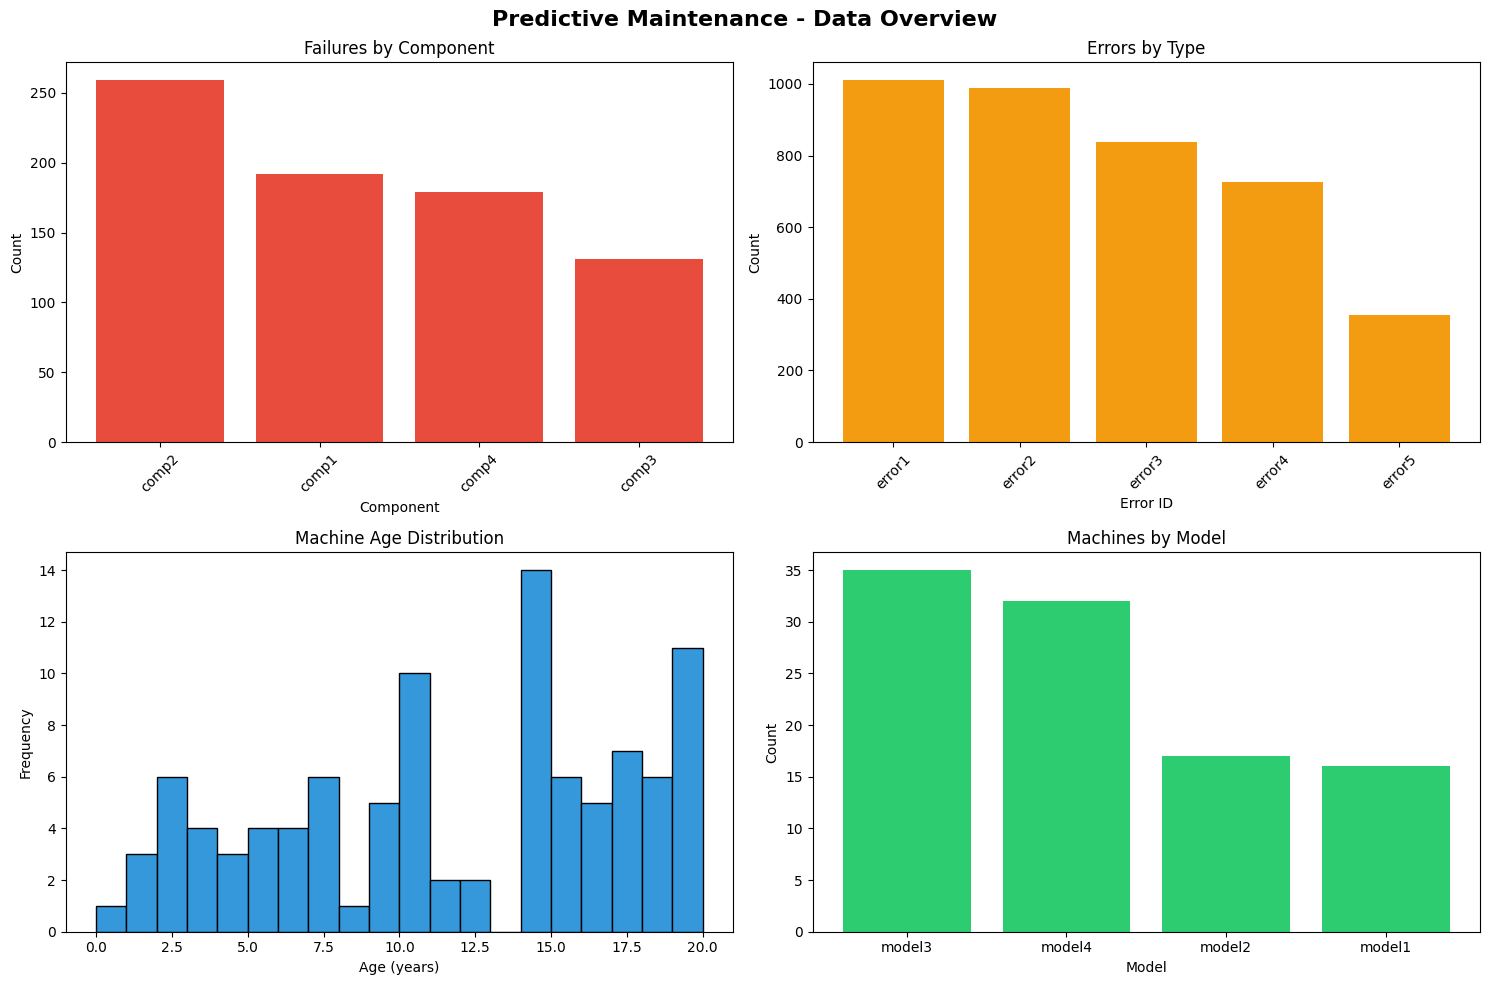

In [26]:
# Creating figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Predictive Maintenance - Data Overview', fontsize=16, fontweight='bold')

# 1. Failures by component
failure_counts = failures_df['failure'].value_counts()
axes[0, 0].bar(failure_counts.index, failure_counts.values, color='#e74c3c')
axes[0, 0].set_title('Failures by Component')
axes[0, 0].set_xlabel('Component')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Errors by type
error_counts = errors_df['errorID'].value_counts()
axes[0, 1].bar(error_counts.index, error_counts.values, color='#f39c12')
axes[0, 1].set_title('Errors by Type')
axes[0, 1].set_xlabel('Error ID')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Machine age distribution
axes[1, 0].hist(machines_df['age'], bins=20, color='#3498db', edgecolor='black')
axes[1, 0].set_title('Machine Age Distribution')
axes[1, 0].set_xlabel('Age (years)')
axes[1, 0].set_ylabel('Frequency')

# 4. Machine models
model_counts = machines_df['model'].value_counts()
axes[1, 1].bar(model_counts.index, model_counts.values, color='#2ecc71')
axes[1, 1].set_title('Machines by Model')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


Sample telemetry readings for a machine:


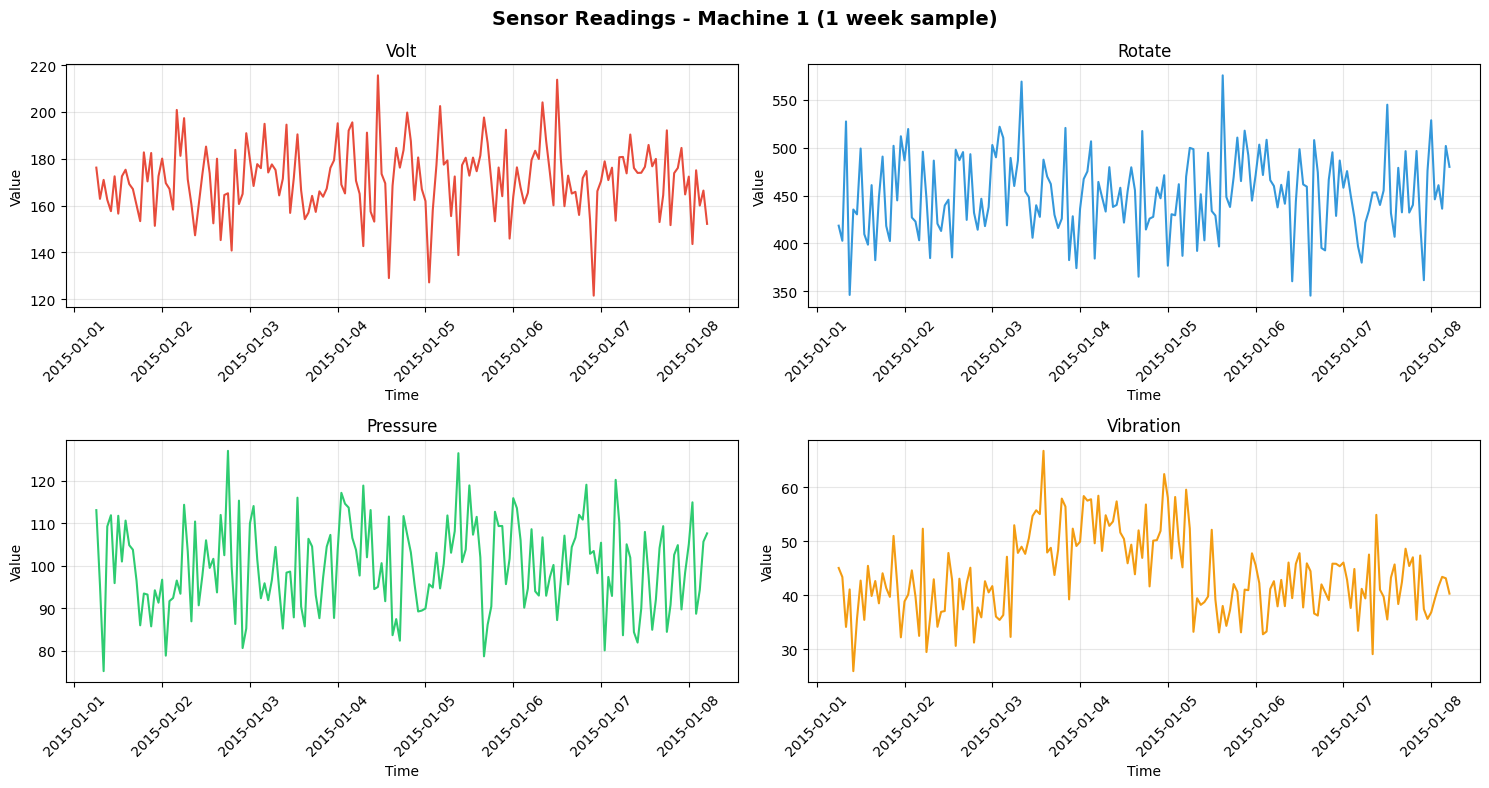

In [27]:
# Telemetry sensor readings visualization
print("\nSample telemetry readings for a machine:")

sample_machine = telemetry_df['machineID'].iloc[0]
sample_data = telemetry_df[telemetry_df['machineID'] == sample_machine].head(168)  # 1 week

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f'Sensor Readings - Machine {sample_machine} (1 week sample)',
              fontsize=14, fontweight='bold')

sensors = ['volt', 'rotate', 'pressure', 'vibration']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, (sensor, color) in enumerate(zip(sensors, colors)):
    row = idx // 2
    col = idx % 2
    axes[row, col].plot(sample_data['datetime'], sample_data[sensor],
                        color=color, linewidth=1.5)
    axes[row, col].set_title(f'{sensor.capitalize()}')
    axes[row, col].set_xlabel('Time')
    axes[row, col].set_ylabel('Value')
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Summary Report

In [30]:
summary = {
    'Dataset': [],
    'Rows': [],
    'Columns': [],
    'Memory (MB)': [],
    'Missing Values': [],
    'Date Range': []
}

for name, df in data.items():
    if df is not None:
        summary['Dataset'].append(name.capitalize())
        summary['Rows'].append(f"{len(df):,}")
        summary['Columns'].append(df.shape[1])
        summary['Missing Values'].append(df.isnull().sum().sum())

        if 'datetime' in df.columns:
            date_range = f"{df['datetime'].min().date()} to {df['datetime'].max().date()}"
        else:
            date_range = "N/A"
        summary['Date Range'].append(date_range)

summary_df = pd.DataFrame(summary)
print("\n")
print(summary_df.to_string(index=False))



    Dataset    Rows  Columns Memory (MB)  Missing Values               Date Range
  Telemetry 876,100        6       40.10               0 2015-01-01 to 2016-01-01
     Errors   3,919        3        0.27               0 2015-01-01 to 2016-01-01
Maintenance   3,286        3        0.22               0 2014-06-01 to 2016-01-01
   Failures     761        3        0.05               0 2015-01-02 to 2015-12-31
   Machines     100        3        0.01               0                      N/A
